In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install "zarr>=2.16.0,<3.0.0" numcodecs umap-learn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.3/211.3 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 120.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 72.8 MB/s eta 0:00:00
  Created wheel for asciitree: filename=asciitree-0.3.3-py3-none-any.whl size=5031 sha256=8afd9e496c3cec6b5db06d7eb31eba2476ecfc03b6b0d8e31ef3d6d25f920757
  Stored in directory: /root/.cache/pip/wheels/a5/d7/98/f56ae733748cd0fa577172bda0e73e0b1f1793c98e09b9e458
Successfully built asciitree


In [3]:
import os
import shutil
import datetime
import gc
import numpy as np
import tensorflow as tf
import random
from typing import Literal
import matplotlib.pyplot as plt
import pandas as pd
import math
from dataclasses import dataclass
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [4]:
ModelType = Literal["pair", "triplet"]

@dataclass
class ModelConfig:
    type: ModelType

@dataclass
class DataConfig:
    authors: int
    authors_range: range
    original_shape: tuple[int, int, int]
    model_input_shape: tuple[int, int, int]

    def __post_init__(self):
        # Validate authors
        assert self.authors > 0, "authors must be positive"

        # Validate range consistency
        assert isinstance(self.authors_range, range), "authors_range must be a range"

        expected_len = self.authors_range.stop - self.authors_range.start
        assert expected_len == self.authors, (
            f"authors ({self.authors}) != range size ({expected_len})"
        )

        # Validate shapes
        assert self.original_shape[-1] in (1, 3), "invalid original channels"
        assert self.model_input_shape[-1] in (1, 3), "invalid input channels"


@dataclass
class TrainingConfig:
    epochs: int
    seed: int
    val_ratio: float

    def __post_init__(self):
        assert 0 < self.val_ratio < 1, "val_ratio must be between 0 and 1"


@dataclass
class BatchConfig:
    train: int
    validation: int
    test: int

    def __post_init__(self):
        assert self.train > 0
        assert self.validation > 0
        assert self.test > 0


@dataclass
class Config:
    project_path: str
    dataset: str
    model: ModelConfig
    data: DataConfig
    training: TrainingConfig
    batch: BatchConfig
    current_time: str

In [5]:
config = Config(
    project_path='drive/MyDrive/author-handwriting-recog',
    dataset='dataset_4_ImagesLinesRemoved_20260310-153450',
    model=ModelConfig(type="triplet"),
    data=DataConfig(
        authors=20,
        authors_range=range(0, 20),
        original_shape=(180, 360, 1),
        model_input_shape=(120, 240, 3),
    ),
    training=TrainingConfig(
        epochs=25,
        seed=42,
        val_ratio=0.25
    ),
    batch=BatchConfig(
        train=16,
        validation=8,
        test=4,
    ),
    current_time=datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
)

In [6]:
def upload_source(source: str, source_dest: str):
    if os.path.exists(source_dest):
        shutil.rmtree(source_dest)

    shutil.copytree(source, source_dest)

In [7]:
src_drive = f"{config.project_path}/src"
src_local = "./src"

In [8]:
src_data_drive = f"{config.project_path}/data/datasets/180_360_90"
src_data_local = f"./dataset"

In [9]:
upload_source(source=src_drive, source_dest=src_local)

In [10]:
upload_source(source=src_data_drive, source_dest=src_data_local)

In [11]:
random.seed(config.training.seed)
np.random.seed(config.training.seed)
tf.random.set_seed(config.training.seed)

In [12]:
from src.io import LoggerFactory
from src.datasets.loaders import SelectiveDataLoader
from src.generators import (
    AugmentationPipeline,
    AugmentationOps,
    AugmentImage,
    BaseGenerator,
    DataGenerator,
    TripletGenerator,
)

In [13]:
from src.models import MobileNetV2Backbone, TripletLoss
from src.training import (
    get_default_callbacks,
    ModelTrainerFactory,
)
from src.evaluator import (
    TripletEvaluator,
)

In [ ]:
from src.evaluator.embedding_utils import EmbeddingExtractor
from src.evaluator.embedding_strategy import (
    StrategyPipeline,
    OneNNStrategy,
    MeanStrategy,
    CentroidStrategy,
    TopKStrategy,
    PatchAggregator,
    VoteAggregator,
    ScoreAggregator,
)
from src.evaluator import EmbeddingEvaluator, EmbeddingVisualizer

In [14]:
logger = LoggerFactory.get_logger(
    "mobile_test_20_4",
    log_dir=f"./logs_{config.current_time}",
    file_prefix=f"mobile_triplet_{config.current_time}"
)

In [15]:
dataset_path = f"dataset/{config.dataset}.tar.gz"

In [16]:
!tar -xzf {dataset_path} -C ./

In [17]:
loader = SelectiveDataLoader(
    dataset_path=f"./{config.dataset}.zarr",
    seed=config.training.seed
)

In [18]:
train, val, test = loader.build(
      author_range=config.data.authors_range,
      validation_fraction=config.training.val_ratio,
  )

11:30:01 - src.datasets.loaders.selective_data_loader - INFO - Total patches selected: 12792
11:30:01 - src.datasets.loaders.selective_data_loader - INFO - Train: 9594 | Val: 3198 | Test: 859
11:30:01 - src.datasets.loaders.selective_data_loader - INFO - Avg non_test patches per author: 639.60 | Min: 467 | Max: 805
11:30:01 - src.datasets.loaders.selective_data_loader - INFO - Avg test patches per author: 42.95 | Min: 34 | Max: 47
11:30:01 - src.datasets.loaders.selective_data_loader - INFO - Image shape: (180, 360)
11:30:01 - src.datasets.loaders.selective_data_loader - INFO - Zarr chunk shape: (64, 180, 360)


In [19]:
ops = AugmentationOps(
    rotation_range=6,
    width_shift_range=0.04,
    height_shift_range=0.05,
    horizontal_flip=False,
    resize_dim=config.data.model_input_shape[:2],
    brightness_delta=0.04,
    contrast_range=(0.95, 1.05),
    noise_stddev=0.01,
    zoom_range=(0.95, 1.05),
)
pipeline_train = AugmentationPipeline([
    ops.rotate,
    ops.zoom,
    ops.shift,
    ops.resize,
    ops.to_rgb,
    ops.clip_255,
    ops.mobilenet_preprocess,
])
pipeline = AugmentationPipeline([
    ops.resize,
    ops.to_rgb,
    ops.clip_255,
    ops.mobilenet_preprocess,
])
augment_train = AugmentImage(pipeline_train)
augment = AugmentImage(pipeline)

In [20]:
train_triplet = TripletGenerator(
    cache=train.cache,
    labels=train.labels,
    indices=train.indices,
    batch_size=config.batch.train,
    seed=config.training.seed,
    augment=augment_train
)
val_triplet = TripletGenerator(
    cache=val.cache,
    labels=val.labels,
    indices=val.indices,
    batch_size=config.batch.validation,
    seed=config.training.seed,
    augment=augment
)
test_triplet = TripletGenerator(
    cache=test.cache,
    labels=test.labels,
    indices=test.indices,
    batch_size=config.batch.test,
    seed=config.training.seed,
    augment=augment
)

In [21]:
def display_generator_info(generator: BaseGenerator):
    config = generator.get_config()
    logger.info(f"Generator: {generator.__class__.__name__}")
    logger.info(f"Number of samples: {config['num_samples']}")
    logger.info(f"Batch size: {config['batch_size']}")
    logger.info(f"Steps per epoch: {config['steps_per_epoch']}")
    logger.info(f"Shape: {config['patch_shape']}")
    logger.info(f"Number of authors: {config['num_authors']}")

In [22]:
display_generator_info(train_triplet)

11:30:01 - mobile_test_20_4 - INFO - Generator: TripletGenerator
11:30:01 - mobile_test_20_4 - INFO - Number of samples: 9594
11:30:01 - mobile_test_20_4 - INFO - Batch size: 16
11:30:01 - mobile_test_20_4 - INFO - Steps per epoch: 600
11:30:01 - mobile_test_20_4 - INFO - Shape: (180, 360)
11:30:01 - mobile_test_20_4 - INFO - Number of authors: 20


In [23]:
display_generator_info(val_triplet)

11:30:01 - mobile_test_20_4 - INFO - Generator: TripletGenerator
11:30:01 - mobile_test_20_4 - INFO - Number of samples: 3198
11:30:01 - mobile_test_20_4 - INFO - Batch size: 8
11:30:01 - mobile_test_20_4 - INFO - Steps per epoch: 400
11:30:01 - mobile_test_20_4 - INFO - Shape: (180, 360)
11:30:01 - mobile_test_20_4 - INFO - Number of authors: 20


In [24]:
display_generator_info(test_triplet)

11:30:02 - mobile_test_20_4 - INFO - Generator: TripletGenerator
11:30:02 - mobile_test_20_4 - INFO - Number of samples: 859
11:30:02 - mobile_test_20_4 - INFO - Batch size: 4
11:30:02 - mobile_test_20_4 - INFO - Steps per epoch: 215
11:30:02 - mobile_test_20_4 - INFO - Shape: (180, 360)
11:30:02 - mobile_test_20_4 - INFO - Number of authors: 20


In [25]:
trainer = ModelTrainerFactory.create(
    backbone=MobileNetV2Backbone(freeze_base=False, fine_tune_at=100),
    input_shape=config.data.model_input_shape,
    num_authors=config.data.authors,
    train_generator=train_triplet,
    val_generator=val_triplet,
    model_name="mobilenet_triplet",
    model_type=config.model.type,
)

11:30:10 - src.training.base_metric_trainer - INFO - [EmbeddingConfig] author=20 | embedding_dim=128 | projection_dim=256


In [26]:
trainer.initialize_model()

/content/src/models/backbones/mobile_net.py:13: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


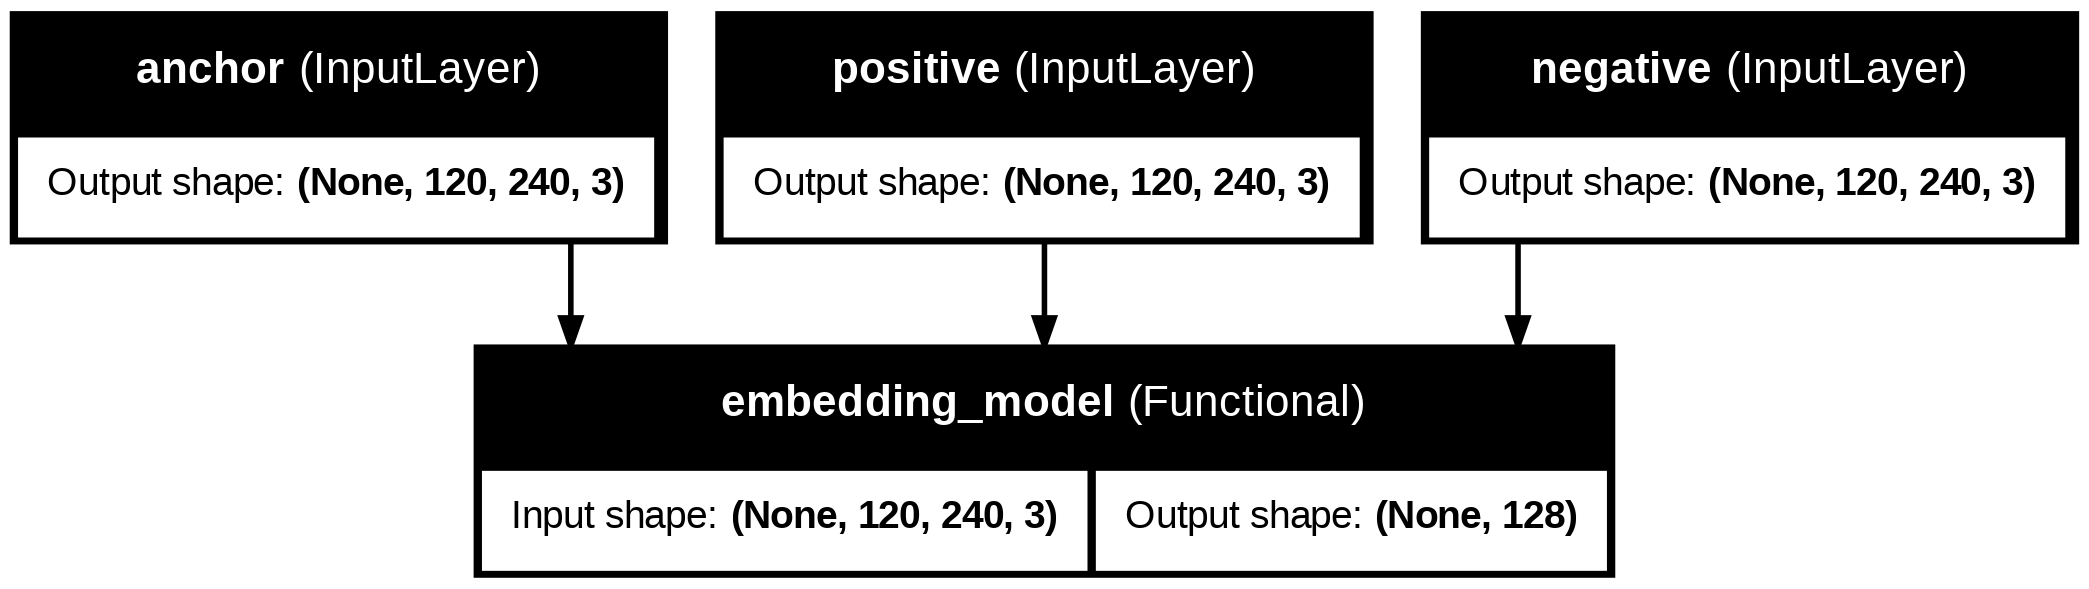

In [27]:
tf.keras.utils.plot_model(
    trainer.siamese_network,
    show_shapes=True,
    show_layer_names=True,
)

In [28]:
trainer.siamese_network.summary()

Model: "siamese_triplet_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ anchor (InputLayer) │ (None, 120, 240,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positive            │ (None, 120, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ negative            │ (None, 120, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_model     │ (None, 128)       │  2,620,352 │ anchor[0][0],     │
│ (Functional)        │                   │            │ positive[0][0],   │
│                     │                   │            │ negative[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,620,352 (10.00 MB)

 Trainable params: 2,223,040 (8.48 MB)

 Non-trainable params: 397,312 (1.52 MB)

In [29]:
trainer.embedding_model.summary()

Model: "embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 120, 240, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 4, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection_dense_1 (Dense)      │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_projection (Dense)    │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l2_normalization                │ (None, 128)            │             0 │
│ (L2Normalization)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,620,352 (10.00 MB)

 Trainable params: 2,223,040 (8.48 MB)

 Non-trainable params: 397,312 (1.52 MB)

In [30]:
trainer.compile(
    loss=TripletLoss(margin=0.4),
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    metrics=[
        tf.keras.metrics.Mean(name="ap_sim"),
        tf.keras.metrics.Mean(name="an_sim"),
        tf.keras.metrics.Mean(name="margin"),
        tf.keras.metrics.Mean(name="triplet_acc"),
    ],
)

In [32]:
callbacks = get_default_callbacks(
    model_name="mobile_siamese_triplet",
    monitor="val_loss",
    mode="min",
    patience=4,
    start_from_epoch=5,
    reduce_lr_patience=2,
)

In [33]:
history = trainer.train_model(
    epochs=config.training.epochs,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/25
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - an_sim: 0.0011 - ap_sim: 0.0333 - loss: 0.3690 - margin: 0.0322 - triplet_acc: 0.5664
Epoch 1: val_loss improved from None to 0.33086, saving model to checkpoints/mobile_siamese_triplet/best.keras

Epoch 1: finished saving model to checkpoints/mobile_siamese_triplet/best.keras
600/600 ━━━━━━━━━━━━━━━━━━━━ 175s 193ms/step - an_sim: -0.0013 - ap_sim: 0.0449 - loss: 0.3563 - margin: 0.0462 - triplet_acc: 0.5925 - val_an_sim: 0.0865 - val_ap_sim: 0.1625 - val_loss: 0.3309 - val_margin: 0.0761 - val_triplet_acc: 0.6304 - learning_rate: 1.0000e-05
Epoch 2/25
599/600 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - an_sim: -0.0046 - ap_sim: 0.1103 - loss: 0.3026 - margin: 0.1148 - triplet_acc: 0.6723
Epoch 2: val_loss improved from 0.33086 to 0.27583, saving model to checkpoints/mobile_siamese_triplet/best.keras

Epoch 2: finished saving model to checkpoints/mobile_siamese_triplet/best.keras
600/600 ━━━━━━━━━━━━━━━━━━━━ 48s 80ms/step - an_sim: -0.005

In [34]:
def plot_keras_history(history: tf.keras.callbacks.History):

    df = pd.DataFrame(history.history)

    metrics = [col for col in df.columns if not col.startswith("val_")]

    n_metrics = len(metrics)
    n_cols = 2
    n_rows = math.ceil(n_metrics / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
    axes = axes.flatten()

    for i, metric in enumerate(metrics):
        ax = axes[i]

        ax.plot(df[metric], label=f"train_{metric}")

        val_metric = f"val_{metric}"
        if val_metric in df.columns:
            ax.plot(df[val_metric], label=f"val_{metric}")

        ax.set_title(metric)
        ax.set_xlabel("Epoch")
        ax.legend()

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

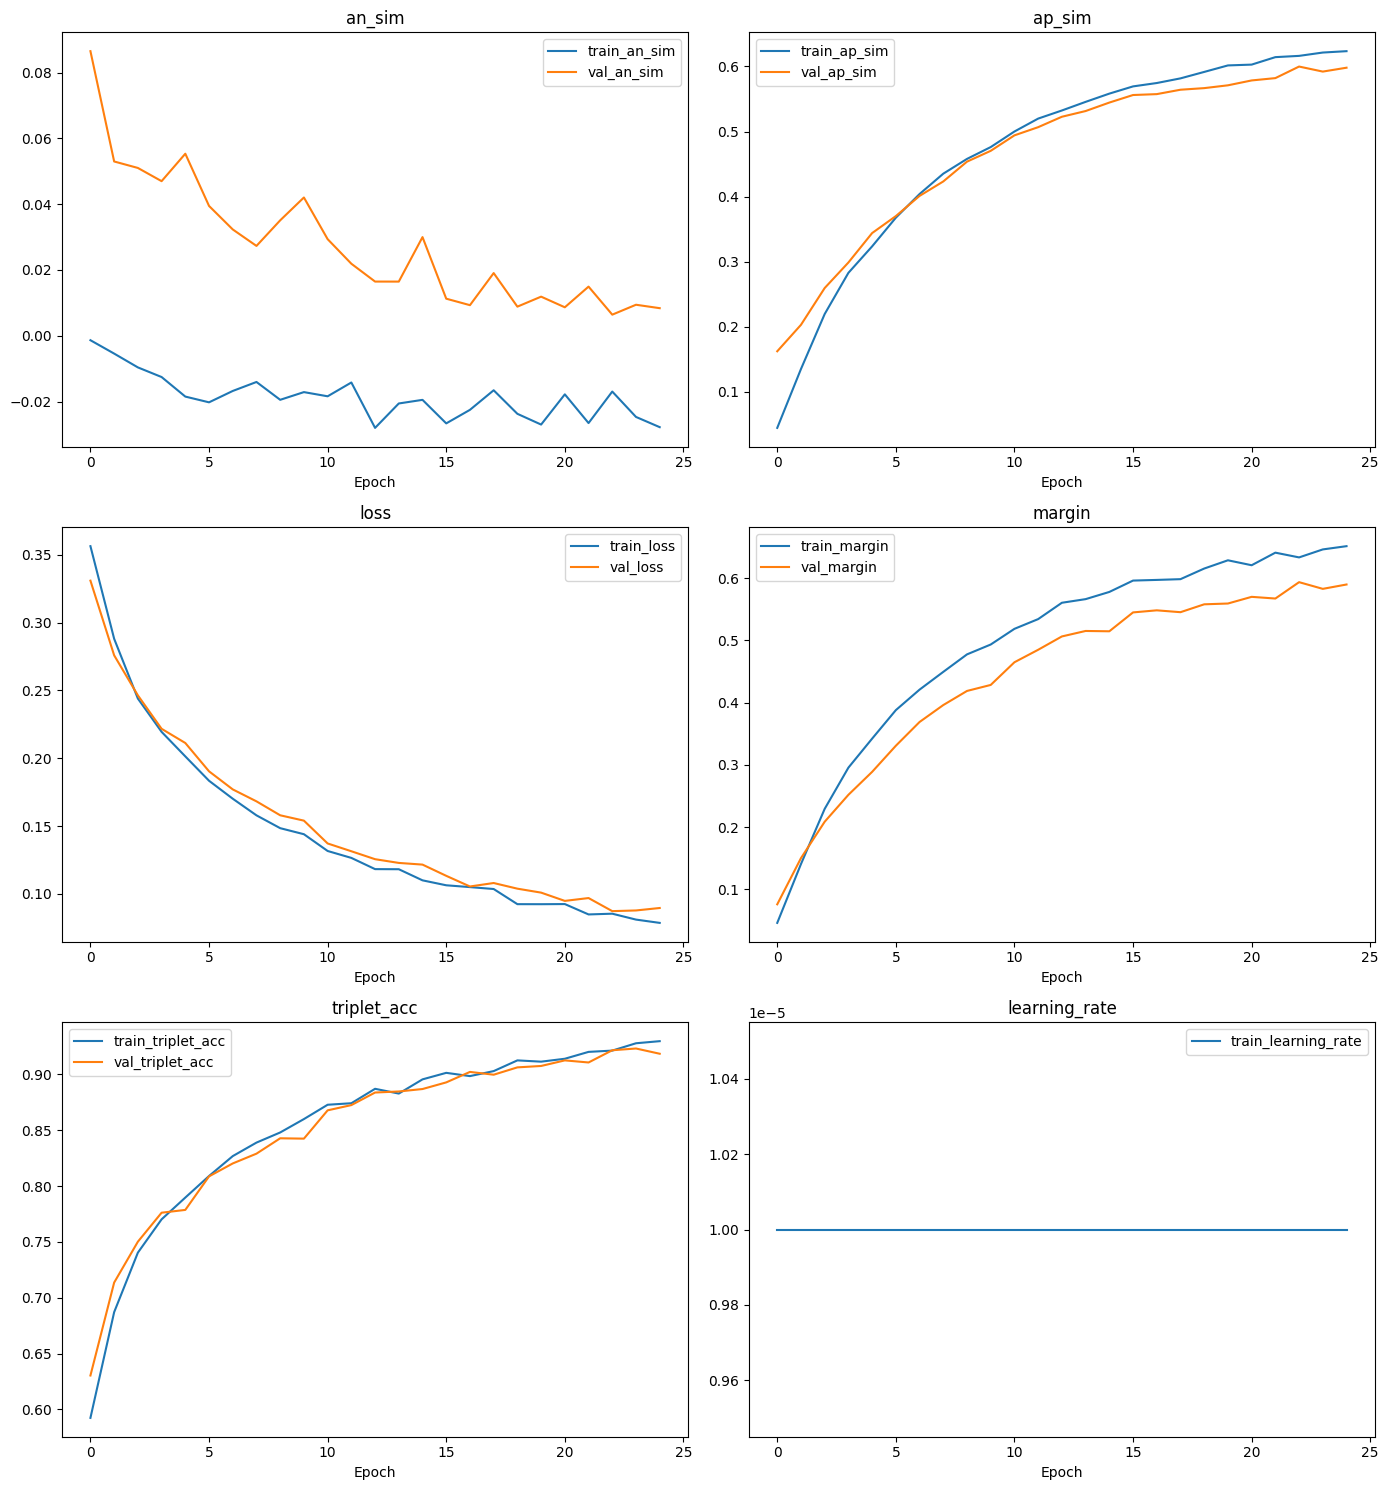

In [35]:
plot_keras_history(history)

In [36]:
os.makedirs("./models", exist_ok=True)
trainer.siamese_network.save(f"./models/mobilenet_siamese_model_20_{config.current_time}.keras")
trainer.embedding_model.save(f"./models/mobilenet_embedding_model_20_{config.current_time}.keras")

In [ ]:
trainer.siamese_network.load_weights("./models/mobilenet_siamese_model_10_20260320-070014.keras")

In [37]:
metrics_val = trainer.evaluate_dict(val_triplet)
metrics_val

400/400 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - an_sim: -0.0012 - ap_sim: 0.5913 - loss: 0.0873 - margin: 0.5925 - triplet_acc: 0.9234


{'an_sim': -0.0011995817767456174,
 'ap_sim': 0.5913262963294983,
 'loss': 0.0872974693775177,
 'margin': 0.5925259590148926,
 'triplet_acc': 0.9233896136283875}

In [38]:
metrics_test = trainer.evaluate_dict(test_triplet)
metrics_test

215/215 ━━━━━━━━━━━━━━━━━━━━ 36s 90ms/step - an_sim: -0.0135 - ap_sim: 0.6552 - loss: 0.0651 - margin: 0.6688 - triplet_acc: 0.9488


{'an_sim': -0.013534558936953545,
 'ap_sim': 0.65523761510849,
 'loss': 0.06506955623626709,
 'margin': 0.6687719225883484,
 'triplet_acc': 0.9487776756286621}

In [41]:
def build_author_confusion_matrix(
    df: pd.DataFrame,
    true_col: str = "author_i",
    pred_col: str = "author_j"
) -> pd.DataFrame:
    authors = sorted(df[true_col].unique())

    cm = confusion_matrix(
        df[true_col],
        df[pred_col],
        labels=authors
    )

    cm_df = pd.DataFrame(
        cm,
        index=authors,
        columns=authors
    )

    return cm_df

In [42]:
def display_heatmap(df: pd.DataFrame) -> None:
    plt.figure(figsize=(10, 8))
    sns.heatmap(df, cmap="Blues", linewidths=0.5)

    plt.xlabel("Predicted Author")
    plt.ylabel("True Author")
    plt.title("Confusion Matrix")
    plt.show()

In [43]:
triplet_evaluator = TripletEvaluator(
    model=trainer,
    logger=logger,
)

In [44]:
triplet_evaluator.data_generator = test_triplet
triplet_report = triplet_evaluator.evaluate()

11:56:16 - mobile_test_20_4 - INFO - === Triplet Evaluation Started ===
11:56:16 - mobile_test_20_4 - INFO - === Collecting triplet results ===
11:56:30 - mobile_test_20_4 - INFO - Total triplets collected: 859
11:56:30 - mobile_test_20_4 - INFO - [LOCAL] acc=0.9453 gap=0.6650 error=0.0547 auc=0.9408
11:56:30 - mobile_test_20_4 - INFO - === Computing global metrics ===
11:56:30 - mobile_test_20_4 - INFO - === Global metrics computed ===
11:56:30 - mobile_test_20_4 - INFO - === Triplet Evaluation Finished ===


In [45]:
triplet_report.local_metrics.auc, triplet_report.local_metrics.triplet_accuracy

(0.9407506088380105, 0.9452852153667055)

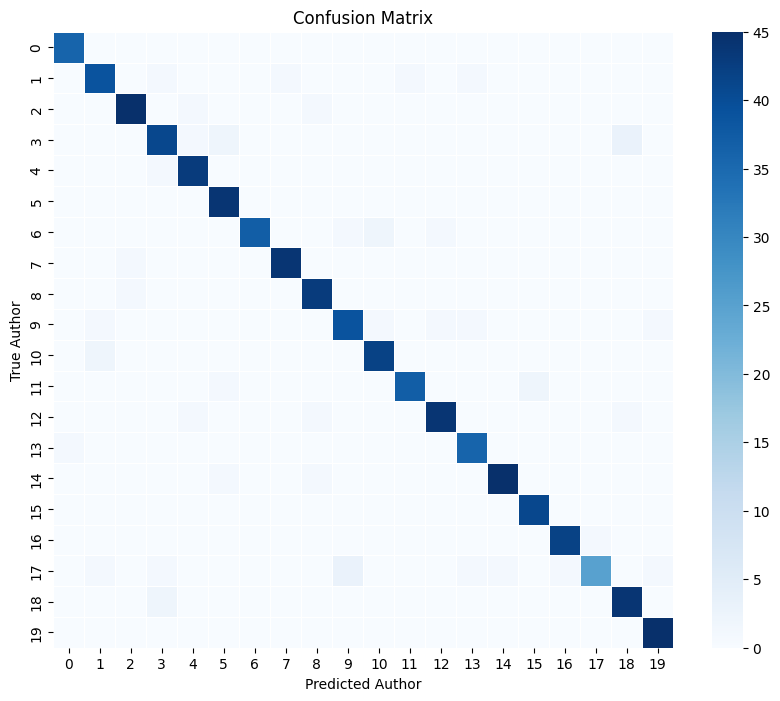

In [46]:
cm_df = build_author_confusion_matrix(
    triplet_report.df_triplets,
    true_col="anchor_label",
    pred_col="pred_label"
)
display_heatmap(cm_df)

In [47]:
triplet_report.global_metrics.df_by_score

,anchor_label,pred_label,accuracy,mean_gap,count,gap_norm,score
0,0,0,1.0,0.801618,36,0.959181,0.959181
1,1,1,1.0,0.627304,39,0.869890,0.869890
2,2,2,1.0,0.867922,45,0.993145,0.993145
3,3,3,1.0,0.651678,41,0.882376,0.882376
4,4,4,1.0,0.619503,43,0.865894,0.865894
5,5,5,1.0,0.653794,44,0.883460,0.883460
6,6,6,1.0,0.611540,37,0.861815,0.861815
7,7,7,1.0,0.810458,44,0.963709,0.963709
8,8,8,1.0,0.827197,43,0.972284,0.972284
9,9,9,1.0,0.560120,39,0.835476,0.835476


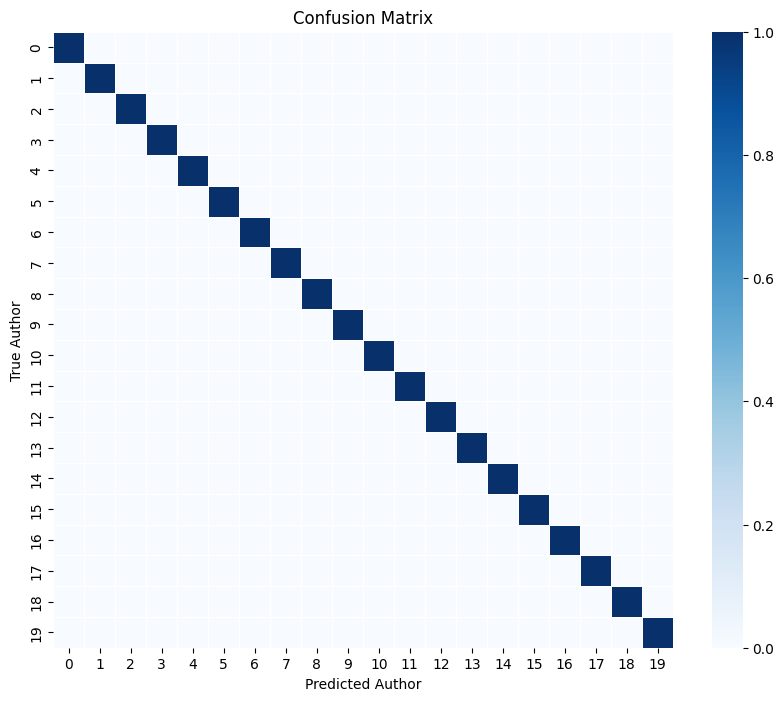

In [48]:
cm_df = build_author_confusion_matrix(
    triplet_report.global_metrics.df_by_score,
    true_col="anchor_label",
    pred_col="pred_label"
)
display_heatmap(cm_df)

In [49]:
train_gen = DataGenerator(
    split=train,
    batch_size=config.batch.train,
    seed=config.training.seed,
    augment=augment_train
)
val_gen = DataGenerator(
    split=val,
    batch_size=config.batch.validation,
    seed=config.training.seed,
    augment=augment
)
test_gen = DataGenerator(
    split=test,
    batch_size=config.batch.test,
    seed=config.training.seed,
    augment=augment
)

In [50]:
display_generator_info(train_gen)

11:57:10 - mobile_test_20_4 - INFO - Generator: DataGenerator
11:57:10 - mobile_test_20_4 - INFO - Number of samples: 9594
11:57:10 - mobile_test_20_4 - INFO - Batch size: 16
11:57:10 - mobile_test_20_4 - INFO - Steps per epoch: 600
11:57:10 - mobile_test_20_4 - INFO - Shape: (180, 360)
11:57:10 - mobile_test_20_4 - INFO - Number of authors: 20


In [51]:
display_generator_info(val_gen)

11:57:11 - mobile_test_20_4 - INFO - Generator: DataGenerator
11:57:11 - mobile_test_20_4 - INFO - Number of samples: 3198
11:57:11 - mobile_test_20_4 - INFO - Batch size: 8
11:57:11 - mobile_test_20_4 - INFO - Steps per epoch: 400
11:57:11 - mobile_test_20_4 - INFO - Shape: (180, 360)
11:57:11 - mobile_test_20_4 - INFO - Number of authors: 20


In [52]:
display_generator_info(test_gen)

11:57:12 - mobile_test_20_4 - INFO - Generator: DataGenerator
11:57:12 - mobile_test_20_4 - INFO - Number of samples: 859
11:57:12 - mobile_test_20_4 - INFO - Batch size: 4
11:57:12 - mobile_test_20_4 - INFO - Steps per epoch: 215
11:57:12 - mobile_test_20_4 - INFO - Shape: (180, 360)
11:57:12 - mobile_test_20_4 - INFO - Number of authors: 20


In [53]:
extractor = EmbeddingExtractor(
    model=trainer.embedding_model,
    logger=logger,
)

In [ ]:
strategy_pipeline = StrategyPipeline(
    strategies=[
        OneNNStrategy(), MeanStrategy(), CentroidStrategy(), TopKStrategy(k=5),
    ],
    aggregators=[PatchAggregator(), VoteAggregator(), ScoreAggregator()],
    logger=logger,
)

In [54]:
emb_evaluator = EmbeddingEvaluator(
    extractor=extractor,
    pipeline=strategy_pipeline,
    logger=logger,
    seed=config.training.seed
)

In [56]:
val_gen_results = emb_evaluator.evaluate(val_gen)

11:57:35 - src.evaluator.embedding_evaluator - INFO - [EmbeddingEvaluator] Starting evaluation
11:57:35 - src.evaluator.embedding_evaluator - INFO - [EmbeddingEvaluator] Preparing embeddings for distance computation
11:57:35 - src.evaluator.embedding_evaluator - INFO - [EmbeddingEvaluator] Embeddings shape=(3198, 128)
11:57:35 - src.evaluator.embedding_evaluator - INFO - [EmbeddingEvaluator] Building author pair similarities
11:57:35 - src.evaluator.embedding_evaluator - INFO - [Pairs] Built in 0.15s
11:57:35 - src.evaluator.embedding_evaluator - INFO - [EmbeddingEvaluator] Running UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


11:57:58 - src.evaluator.embedding_evaluator - INFO - [EmbeddingEvaluator] UMAP completed in 22.52s
11:57:58 - src.evaluator.embedding_evaluator - INFO - [UMAP] Completed in 22.53s
11:57:58 - src.evaluator.embedding_evaluator - INFO - [EmbeddingEvaluator] Computing intra/inter distances
11:57:58 - src.evaluator.embedding_evaluator - INFO - [EmbeddingEvaluator] intra=0.4108 | inter=0.9870 | ratio=0.4162 | time=0.03s
11:57:58 - src.evaluator.embedding_evaluator - INFO - [EmbeddingEvaluator] Evaluating strategies: ['1nn', 'mean', 'centroid', 'topk']
11:57:58 - src.evaluator.embedding_strategies - INFO - [Pipeline] Applying strategy: 1nn
11:57:58 - src.evaluator.embedding_strategies - INFO - [Strategy:1NN] Computing similarity matrix
11:57:58 - src.evaluator.embedding_strategies - INFO - [Strategy:1NN] Accuracy=0.6523
11:57:58 - src.evaluator.embedding_evaluator - INFO - [Strategy: 1nn] patch_acc=0.6523 | vote_acc=1.0000 | score_acc=0.4500 | time=0.09s
11:57:58 - src.evaluator.embedding_st

In [57]:
logger.info(f"Intra distance: {val_gen_results.intra_distance}")
logger.info(f"Inter distance: {val_gen_results.inter_distance}")

for strategy_name, agg_results in val_gen_results.strategy_results.items():

    logger.info(f"Strategy: {strategy_name}")

    for agg_name, result in agg_results.items():
        acc = result.metrics.get("accuracy", np.nan)
        logger.info(f"{agg_name.capitalize()} accuracy: {acc:.4f}")

    logger.info(f"{'-'*40}")

11:58:11 - mobile_test_20_4 - INFO - Intra distance: 0.41078808469200634
11:58:11 - mobile_test_20_4 - INFO - Inter distance: 0.9870464568928261
11:58:11 - mobile_test_20_4 - INFO - Strategy: 1nn
11:58:11 - mobile_test_20_4 - INFO - Patch accuracy: 0.6523
11:58:11 - mobile_test_20_4 - INFO - Vote accuracy:  1.0000
11:58:11 - mobile_test_20_4 - INFO - Score accuracy: 0.4500
11:58:11 - mobile_test_20_4 - INFO - ----------------------------------------
11:58:11 - mobile_test_20_4 - INFO - Strategy: mean
11:58:11 - mobile_test_20_4 - INFO - Patch accuracy: 0.6357
11:58:11 - mobile_test_20_4 - INFO - Vote accuracy:  0.8500
11:58:11 - mobile_test_20_4 - INFO - Score accuracy: 0.4500
11:58:11 - mobile_test_20_4 - INFO - ----------------------------------------
11:58:11 - mobile_test_20_4 - INFO - Strategy: centroid
11:58:11 - mobile_test_20_4 - INFO - Patch accuracy: 0.6801
11:58:11 - mobile_test_20_4 - INFO - Vote accuracy:  1.0000
11:58:11 - mobile_test_20_4 - INFO - Score accuracy: 0.5000


In [59]:
test_gen_results = emb_evaluator.evaluate(test_gen)

11:58:22 - src.evaluator.embedding_evaluator - INFO - [EmbeddingEvaluator] Starting evaluation
11:58:22 - src.evaluator.embedding_evaluator - INFO - [EmbeddingEvaluator] Preparing embeddings for distance computation
11:58:22 - src.evaluator.embedding_evaluator - INFO - [EmbeddingEvaluator] Embeddings shape=(859, 128)
11:58:22 - src.evaluator.embedding_evaluator - INFO - [EmbeddingEvaluator] Building author pair similarities
11:58:22 - src.evaluator.embedding_evaluator - INFO - [Pairs] Built in 0.04s
11:58:22 - src.evaluator.embedding_evaluator - INFO - [EmbeddingEvaluator] Running UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


11:58:24 - src.evaluator.embedding_evaluator - INFO - [EmbeddingEvaluator] UMAP completed in 2.06s
11:58:24 - src.evaluator.embedding_evaluator - INFO - [UMAP] Completed in 2.06s
11:58:24 - src.evaluator.embedding_evaluator - INFO - [EmbeddingEvaluator] Computing intra/inter distances
11:58:24 - src.evaluator.embedding_evaluator - INFO - [EmbeddingEvaluator] intra=0.3406 | inter=1.0203 | ratio=0.3338 | time=0.03s
11:58:24 - src.evaluator.embedding_evaluator - INFO - [EmbeddingEvaluator] Evaluating strategies: ['1nn', 'mean', 'centroid', 'topk']
11:58:24 - src.evaluator.embedding_strategies - INFO - [Pipeline] Applying strategy: 1nn
11:58:24 - src.evaluator.embedding_strategies - INFO - [Strategy:1NN] Computing similarity matrix
11:58:24 - src.evaluator.embedding_strategies - INFO - [Strategy:1NN] Accuracy=0.8533
11:58:24 - src.evaluator.embedding_evaluator - INFO - [Strategy: 1nn] patch_acc=0.8533 | vote_acc=1.0000 | score_acc=0.6000 | time=0.02s
11:58:24 - src.evaluator.embedding_stra

In [60]:
logger.info(f"Intra distance: {test_gen_results.intra_distance}")
logger.info(f"Inter distance: {test_gen_results.inter_distance}")

for strategy_name, agg_results in test_gen_results.strategy_results.items():

    logger.info(f"Strategy: {strategy_name}")

    for agg_name, result in agg_results.items():
        acc = result.metrics.get("accuracy", np.nan)
        logger.info(f"{agg_name.capitalize()} accuracy: {acc:.4f}")

    logger.info(f"{'-'*40}")

11:59:18 - mobile_test_20_4 - INFO - Intra distance: 0.34057579661153026
11:59:18 - mobile_test_20_4 - INFO - Inter distance: 1.0202696331469894
11:59:18 - mobile_test_20_4 - INFO - Strategy: 1nn
11:59:18 - mobile_test_20_4 - INFO - Patch accuracy: 0.8533
11:59:18 - mobile_test_20_4 - INFO - Vote accuracy:  1.0000
11:59:18 - mobile_test_20_4 - INFO - Score accuracy: 0.6000
11:59:18 - mobile_test_20_4 - INFO - ----------------------------------------
11:59:18 - mobile_test_20_4 - INFO - Strategy: mean
11:59:18 - mobile_test_20_4 - INFO - Patch accuracy: 0.7078
11:59:18 - mobile_test_20_4 - INFO - Vote accuracy:  0.8500
11:59:18 - mobile_test_20_4 - INFO - Score accuracy: 0.4000
11:59:18 - mobile_test_20_4 - INFO - ----------------------------------------
11:59:18 - mobile_test_20_4 - INFO - Strategy: centroid
11:59:18 - mobile_test_20_4 - INFO - Patch accuracy: 0.7579
11:59:18 - mobile_test_20_4 - INFO - Vote accuracy:  1.0000
11:59:18 - mobile_test_20_4 - INFO - Score accuracy: 0.4500


In [61]:
viz = EmbeddingVisualizer(
    report=test_gen_results,
    logger=logger,
    loader=test.loader,
)

In [ ]:
viz.set_strategy("1nn")

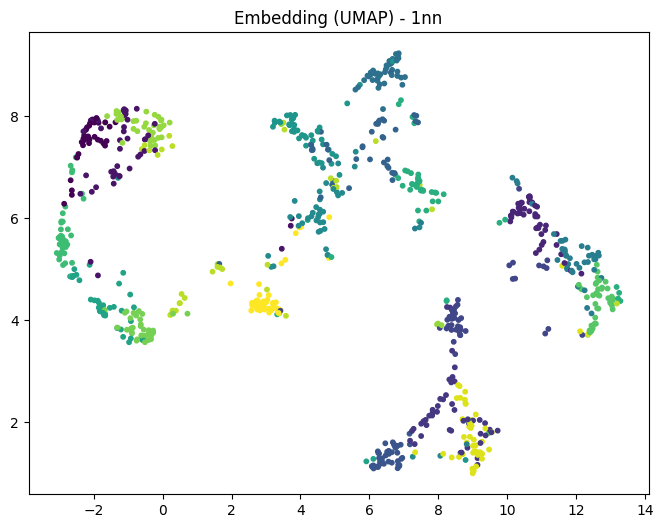

In [62]:
viz.plot_embeddings_2d()

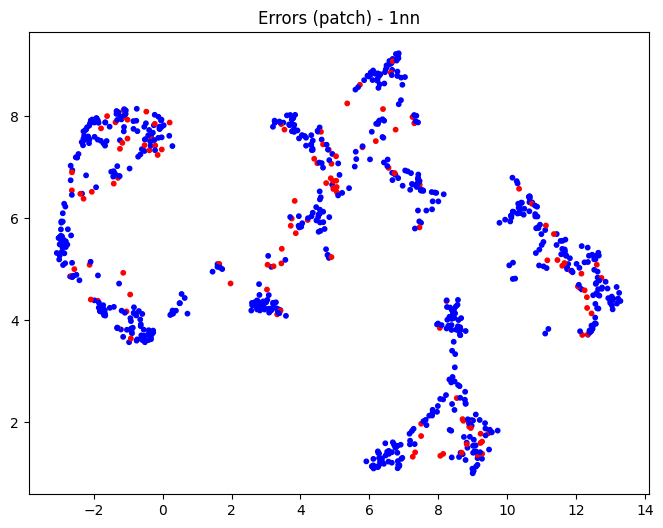

In [63]:
viz.plot_errors_2d(level="patch")

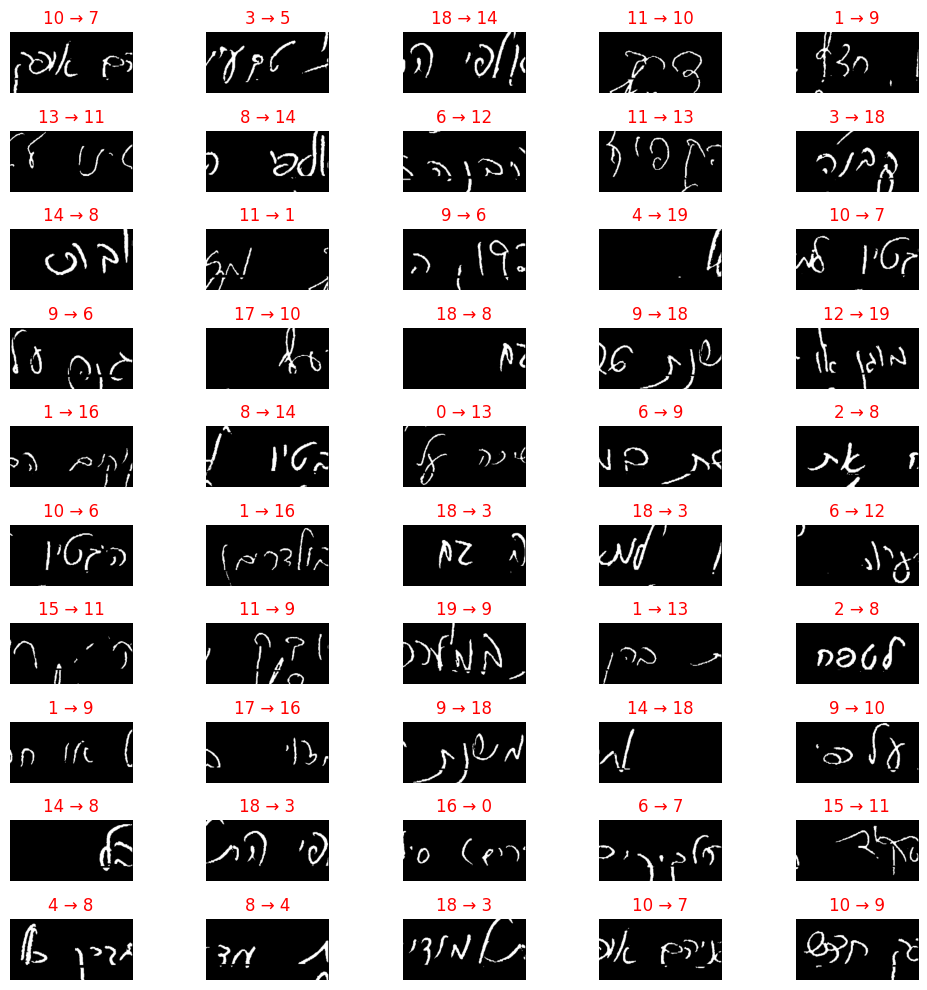

In [64]:
viz.plot_error_images()

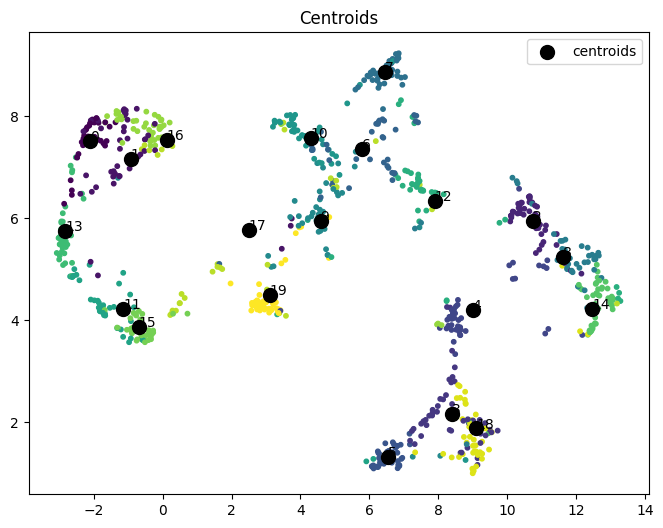

In [65]:
viz.plot_centroids()

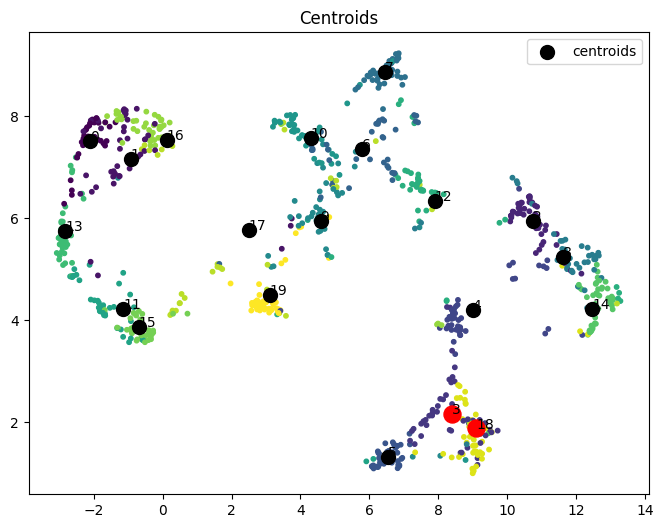

In [69]:
viz.plot_centroids([18, 3])

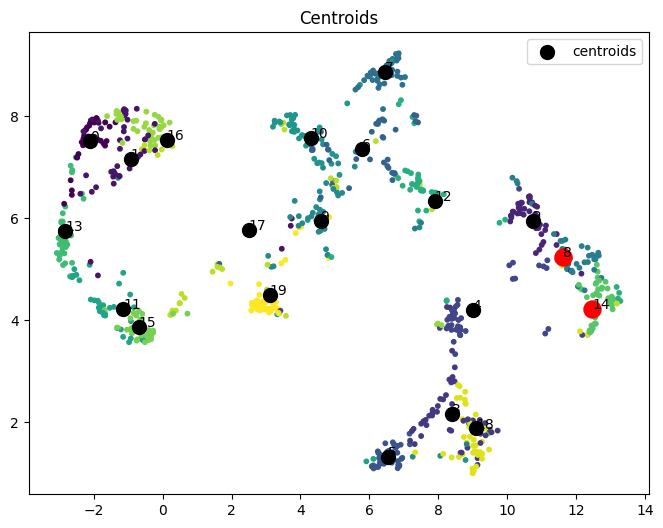

In [70]:
viz.plot_centroids([14, 8])

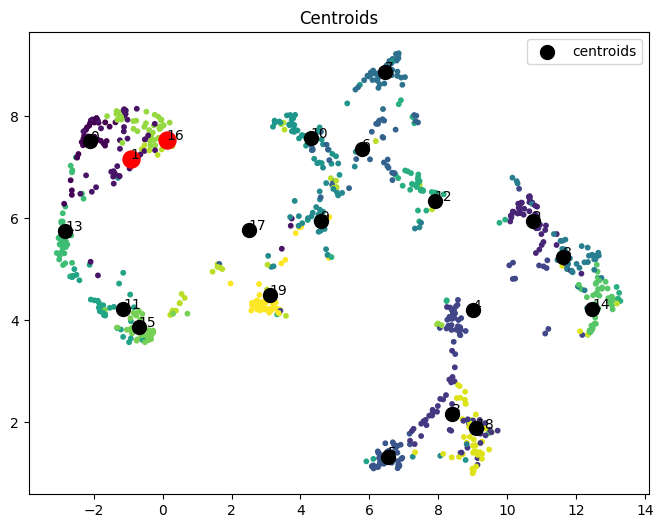

In [71]:
viz.plot_centroids([1, 16])

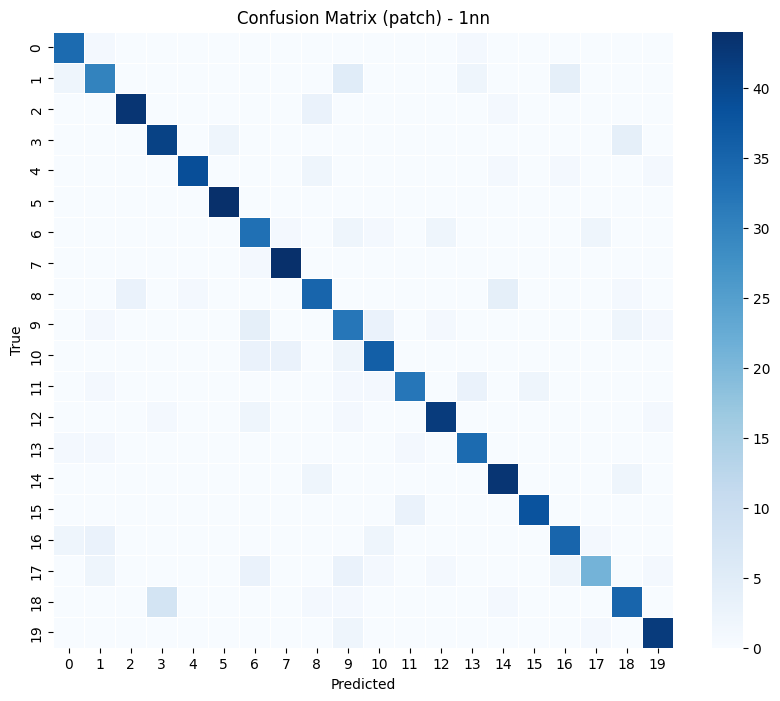

In [67]:
viz.plot_confusion(level="patch")

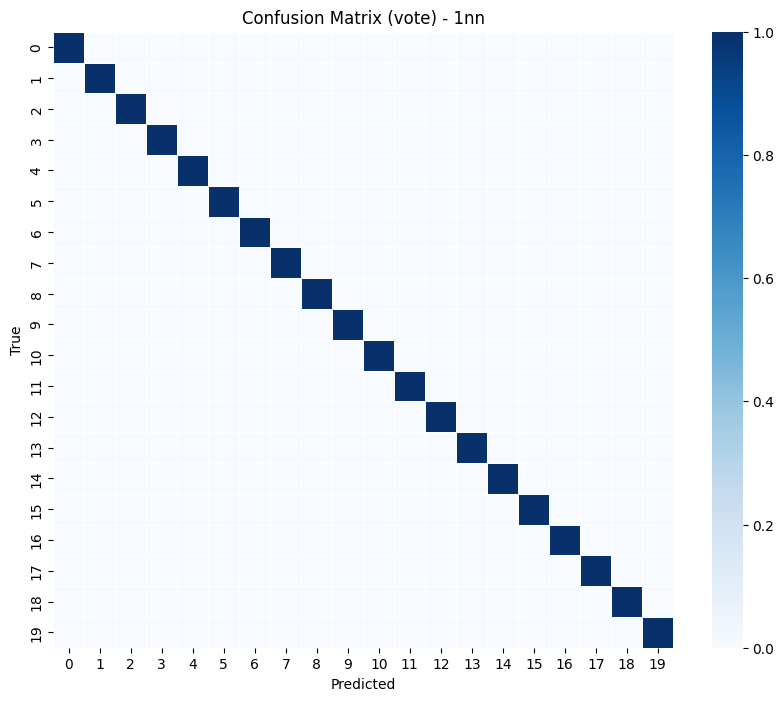

In [66]:
viz.plot_confusion(level="vote")

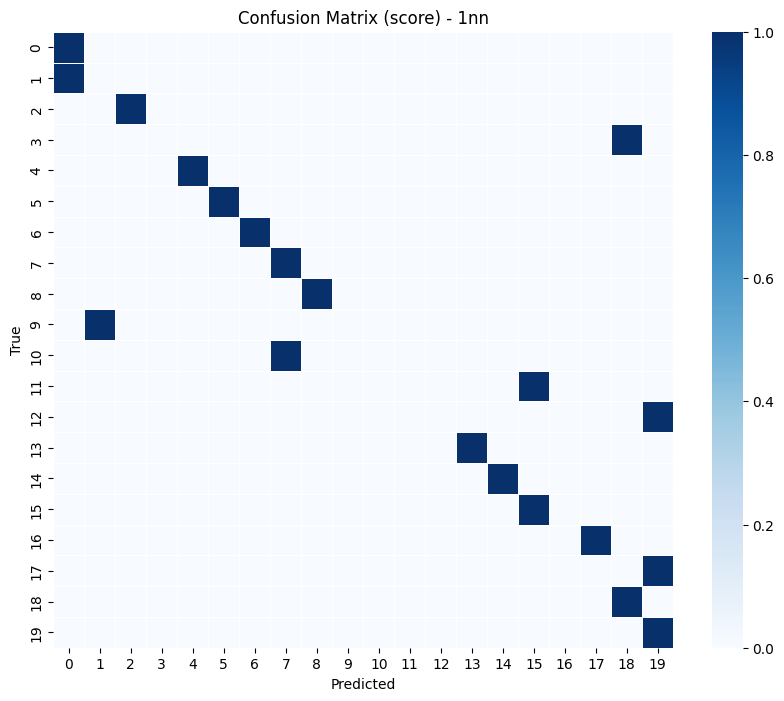

In [68]:
viz.plot_confusion(level="score")